<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 13

Anna Clara Belmiro Tonial 17097091

Laura Tavares Paes 17097601

Lavinia Ramos Lourenço 17081100

###Importação do banco de de dados "Iris"

####Sobre o banco de dados

* Link de acesso: https://archive.ics.uci.edu/dataset/53/iris

* Autoria: Fisher, R. (1936). Iris [Conjunto de dados]. Repositório de Aprendizado de Máquina da UCI. https://doi.org/10.24432/C56C76.

* Data de acesso: 05/06/2026

* Unidade das variáveis: cm (comprimento e largura de sépalas e pétalas), variável nominal (classe/espécie da planta).





In [ ]:
!pip install ucimlrepo

from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

In [ ]:
import pandas as pd

print("Tabela X (Características):")
display(X.head())

print("\nTabela y (Alvos/Classes):")
display(y.head())

In [ ]:
df_completo = pd.concat([X, y], axis=1)

print("Tabela Unificada (Iris Completo):")
display(df_completo.head())

### 1. Distribuição Normal

A distribuição normal é uma distribuição de probabilidade contínua, também chamada de função de densidade de probabilidade, a qual é dada por:

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Onde:
* $x \in \mathbb{R}$: valor da variável aleatória contínua.
* $\mu \in \mathbb{R}$: média populacional.
* $\sigma \in \mathbb{R}^+$: desvio padrão populacional ($\sigma > 0$).
* $\pi \approx 3.14159$ e $e \approx 2.71828$.

A distribuição Normal é representada por $N$, e diz que uma variável aleatória contínua $X$ possui distribuição Normal com média $\mu$ e variância $\sigma^2$: $X$ ~ $N$ ($\mu$, $\sigma^2$). Seu gráfico possui formato de sino, o que implica que valores próximos da média possuem maior probabilidade de ocorrência, enquanto os extremos tem menor probabilidade. Além disso, esta distribuição é simétrica, o que significa que média = mediana = moda.

Na prática, muitos fenômenos naturais e do dia-a-dia se assemelham à distribuição Normal, e isso pode ser explicado pelo teorema do limite central, que afirma que, conforme o tamanho de uma amostra aumenta, a distribuição das médias amostrais aproxima-se de uma distribuição normal, independentemente do formato da distribuição original da população, o que afirma a relevância desta distribuição.


#### B. Representação prática e diferenciação
* **Medida de um organismo:** No contexto do banco de dados "Iris", medidas físicas diretas de um organismo individual, como o comprimento da sépala, frequentemente seguem uma distribuição aproximadamente Normal devido à influência de múltiplos fatores genéticos e ambientais independentes atuando de forma aditiva.
* **Estatística amostral:** Diferente de uma medida física individual, a média amostral $(\bar{X})$ calculada a partir de uma amostra de plantas também segue uma distribuição normal (conforme o tamanho da amostra aumenta), mas com uma variabilidade menor.

#### C. Parâmetros e efeitos sobre a curva
* **$\mu$:** Controla o centro (ponto de simetria) da curva. Mudar $\mu$ desloca a curva horizontalmente para a esquerda ou direita, sem alterar sua forma ou dispersão.
* **$\sigma$:** Determina a dispersão. Valores menores de $\sigma$ concentram a curva ao redor da média, tornando-a mais alta e estreita. Valores maiores espalham os dados, deixando a curva achatada e larga.

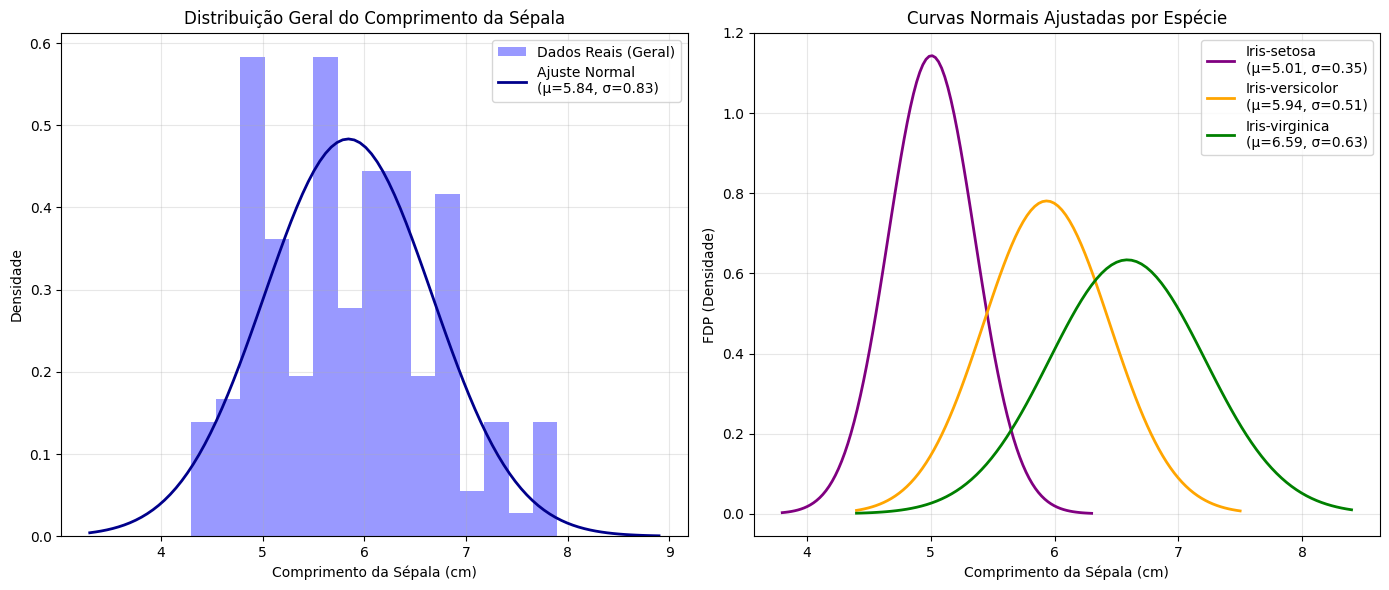

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# Garante que os dados estão carregados caso a célula anterior não tenha sido executada nesta sessão
try:
    df_completo
except NameError:
    from ucimlrepo import fetch_ucirepo
    iris = fetch_ucirepo(id=53)
    X = iris.data.features
    y = iris.data.targets
    df_completo = pd.concat([X, y], axis=1)

# Vamos extrair a variável 'sepal length' para as análises
sepal_length = df_completo['sepal length']
classes = df_completo['class']

plt.figure(figsize=(14, 6))

# Grafico 1: Ajuste geral e o efeito da média
plt.subplot(1, 2, 1)
# Histograma dos dados reais de sepal length
plt.hist(sepal_length, bins=15, density=True, alpha=0.4, color='blue', label='Dados Reais (Geral)')
# Ajustando a curva normal teórica
mu_geral, sigma_geral = stats.norm.fit(sepal_length)
x_axis = np.linspace(sepal_length.min() - 1, sepal_length.max() + 1, 100)
plt.plot(x_axis, stats.norm.pdf(x_axis, mu_geral, sigma_geral), color='darkblue', lw=2,
         label=f"Ajuste Normal\n(μ={mu_geral:.2f}, σ={sigma_geral:.2f})")

plt.title('Distribuição Geral do Comprimento da Sépala')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('Densidade')
plt.grid(True, alpha=0.3)
plt.legend()

# Grafico 2: Variação de Posição (mu) e Dispersão (sigma) por Espécie
plt.subplot(1, 2, 2)
colors = {'Iris-setosa': 'purple', 'Iris-versicolor': 'orange', 'Iris-virginica': 'green'}

for espec_name, color in colors.items():
    # Filtrando os dados por espécie
    sub_data = df_completo[df_completo['class'] == espec_name]['sepal length']
    if len(sub_data) > 0:
        mu, sigma = stats.norm.fit(sub_data)
        x_spec = np.linspace(sub_data.min() - 0.5, sub_data.max() + 0.5, 100)
        # Plotando a curva teórica de cada espécie
        plt.plot(x_spec, stats.norm.pdf(x_spec, mu, sigma), color=color, lw=2,
                 label=f"{espec_name}\n(μ={mu:.2f}, σ={sigma:.2f})")

plt.title('Curvas Normais Ajustadas por Espécie')
plt.xlabel('Comprimento da Sépala (cm)')
plt.ylabel('FDP (Densidade)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Condições para aplicação e limitações do banco de dados

Ao aplicar a hipótese de normalidade ao dataset **Iris**, algumas considerações práticas devem ser observadas:

1. **Condições de normalidade:**
   * Os testes paramétricos tradicionais assumem que as observações residuais dentro de cada grupo seguem uma distribuição Normal com variâncias aproximadamente homogêneas (homocedasticidade).
   
2. **Limitações do banco de dados:**
   * **Tamanho de amostra pequeno ($n = 150$ total, $50$ por classe):** Embora seja suficiente para análises básicas, amostras de 50 indivíduos por espécie podem ter o poder estatístico reduzido para verificar a aderência perfeita à curva normal através de testes formais.
   * Apesar de as variáveis de comprimento e largura serem teoricamente contínuas, elas foram medidas com precisão de uma casa decimal (em cm). A presença de valores repetidos pode criar degraus discretos que se afastam ligeiramente da curva normal teórica contínua.
   * **Independência:** A aplicação clássica assume amostragem aleatória simples. Caso as flores tenham sido colhidas de canteiros adjacentes específicos no mesmo dia, haveria autocorrelação espacial, violando a hipótese de independência estatística.

### Contextualizado

**Contexto Biológico:**
Um botânico está estudando a preservação das espécies de flores do gênero *Iris* em uma reserva ecológica. Para monitorar a saúde e o desenvolvimento das populações, o pesquisador foca na espécie **Iris-versicolor**, cujo comprimento da sépala é um indicador importante de maturidade física. Historicamente, os dados da *Iris-versicolor* mostram que o comprimento da sépala segue uma distribuição aproximadamente normal com média $\mu \approx 5.94$ cm e desvio padrão $\sigma \approx 0.51$ cm.

**Perguntas de Pesquisa (Padronizadas para 5% nas caudas extremas e 70% no intervalo central):**
1. Qual a probabilidade de uma planta da espécie *Iris-versicolor* selecionada ao acaso apresentar uma sépala considerada "muito curta", isto é, com comprimento **abaixo de 5.10 cm** (limite correspondente aos 5% inferiores da população)?
2. Qual a proporção de plantas cujo comprimento de sépala se encontra na faixa típica de crescimento saudável, definida de forma simétrica para conter exatamente 70% da população, ou seja, **entre 5.41 cm e 6.47 cm**?
3. Plantas com sépalas **maiores que 6.78 cm** são consideradas gigantes (limite correspondente aos 5% superiores da população). Qual a probabilidade de encontrarmos um indivíduo gigante na população?
4. O botânico deseja identificar o valor limite de comprimento de sépala abaixo do qual estão os **15%** dos menores indivíduos (para fins de triagem de subdesenvolvimento). Qual é esse comprimento correspondente ao **percentil 15**?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parâmetros ajustados para a espécie Iris-versicolor
mu = 5.94
sigma = 0.51

# 1. Cálculos de Probabilidade com limites padronizados (5% nas pontas e 70% no centro)
p_abaixo = stats.norm.cdf(5.10, loc=mu, scale=sigma)
p_entre = stats.norm.cdf(6.47, loc=mu, scale=sigma) - stats.norm.cdf(5.41, loc=mu, scale=sigma)
p_acima = 1 - stats.norm.cdf(6.78, loc=mu, scale=sigma)
percentil_15 = stats.norm.ppf(0.15, loc=mu, scale=sigma)

print(f"--- RESULTADOS NUMÉRICOS PADRONIZADOS (5% / 70% / 5%) ---")
print(f"1. P(X < 5.10 cm)  = {p_abaixo:.4f} ({p_abaixo*100:.2f}%)  [Alvo: ~5.00%]")
print(f"2. P(5.41 < X < 6.47) = {p_entre:.4f} ({p_entre*100:.2f}%)  [Alvo: ~70.00%]")
print(f"3. P(X > 6.78 cm)  = {p_acima:.4f} ({p_acima*100:.2f}%)  [Alvo: ~5.00%]")
print(f"4. Percentil 15     = {percentil_15:.2f} cm (15% das flores têm comprimento menor ou igual a este)")

--- RESULTADOS NUMÉRICOS PADRONIZADOS (5% / 70% / 5%) ---
1. P(X < 5.10 cm)  = 0.0498 (4.98%)  [Alvo: ~5.00%]
2. P(5.41 < X < 6.47) = 0.7013 (70.13%)  [Alvo: ~70.00%]
3. P(X > 6.78 cm)  = 0.0498 (4.98%)  [Alvo: ~5.00%]
4. Percentil 15     = 5.41 cm (15% das flores têm comprimento menor ou igual a este)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parâmetros ajustados para a espécie Iris-versicolor
mu = 5.94
sigma = 0.51

# 1. Cálculos de Probabilidade com limites padronizados (5% nas pontas e 70% no centro)
p_abaixo = stats.norm.cdf(5.10, loc=mu, scale=sigma)
p_entre = stats.norm.cdf(6.47, loc=mu, scale=sigma) - stats.norm.cdf(5.41, loc=mu, scale=sigma)
p_acima = 1 - stats.norm.cdf(6.78, loc=mu, scale=sigma)
percentil_15 = stats.norm.ppf(0.15, loc=mu, scale=sigma)

print(f"--- RESULTADOS NUMÉRICOS PADRONIZADOS (5% / 70% / 5%) ---")
print(f"1. P(X < 5.10 cm)  = {p_abaixo:.4f} ({p_abaixo*100:.2f}%)  [Alvo: ~5.00%]")
print(f"2. P(5.41 < X < 6.47) = {p_entre:.4f} ({p_entre*100:.2f}%)  [Alvo: ~70.00%]")
print(f"3. P(X > 6.78 cm)  = {p_acima:.4f} ({p_acima*100:.2f}%)  [Alvo: ~5.00%]")
print(f"4. Percentil 15     = {percentil_15:.2f} cm (15% das flores têm comprimento menor ou igual a este)")

--- RESULTADOS NUMÉRICOS PADRONIZADOS (5% / 70% / 5%) ---
1. P(X < 5.10 cm)  = 0.0498 (4.98%)  [Alvo: ~5.00%]
2. P(5.41 < X < 6.47) = 0.7013 (70.13%)  [Alvo: ~70.00%]
3. P(X > 6.78 cm)  = 0.0498 (4.98%)  [Alvo: ~5.00%]
4. Percentil 15     = 5.41 cm (15% das flores têm comprimento menor ou igual a este)


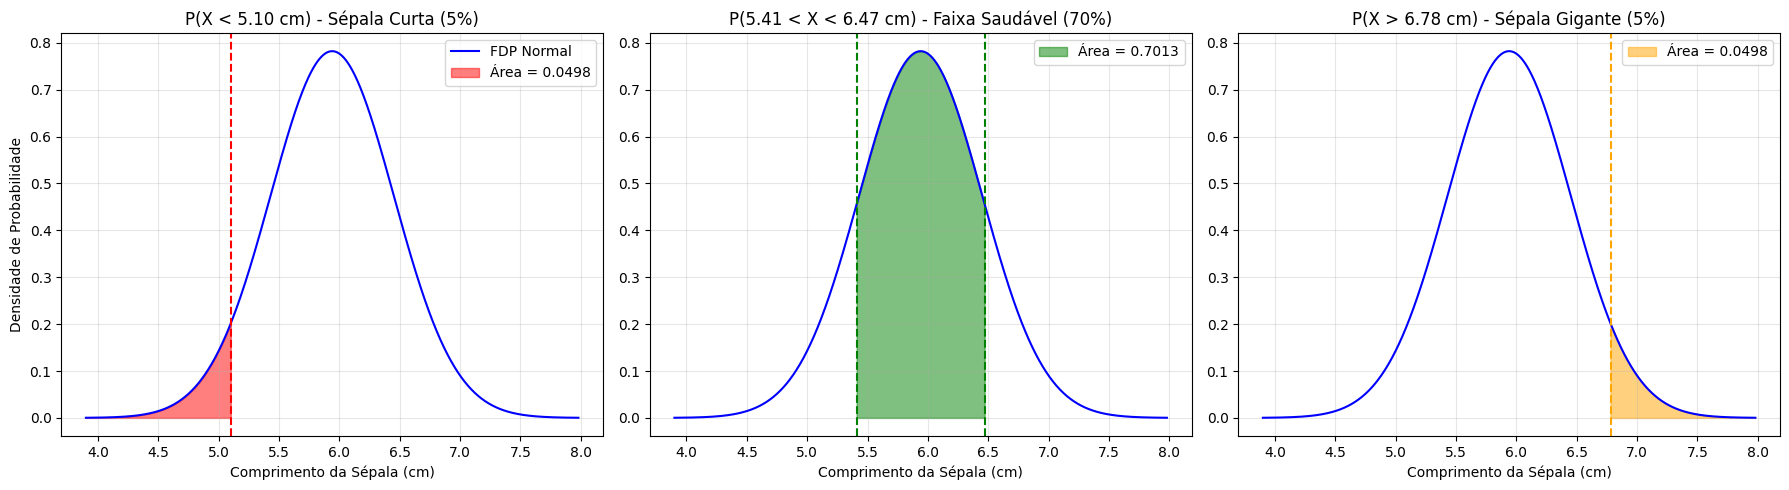

In [ ]:
# 2. Plotagem das Curvas de Densidade e Áreas Sombreadas com os novos limites padronizados
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y_pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: P(X < 5.10 cm)
axes[0].plot(x, y_pdf, 'b-', label='FDP Normal')
x_fill1 = np.linspace(mu - 4*sigma, 5.10, 500)
axes[0].fill_between(x_fill1, stats.norm.pdf(x_fill1, loc=mu, scale=sigma), color='red', alpha=0.5,
                     label=f'Área = {p_abaixo:.4f}')
axes[0].axvline(5.10, color='red', linestyle='--')
axes[0].set_title('P(X < 5.10 cm) - Sépala Curta (5%)')
axes[0].set_xlabel('Comprimento da Sépala (cm)')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: P(5.41 < X < 6.47 cm)
axes[1].plot(x, y_pdf, 'b-')
x_fill2 = np.linspace(5.41, 6.47, 500)
axes[1].fill_between(x_fill2, stats.norm.pdf(x_fill2, loc=mu, scale=sigma), color='green', alpha=0.5,
                     label=f'Área = {p_entre:.4f}')
axes[1].axvline(5.41, color='green', linestyle='--')
axes[1].axvline(6.47, color='green', linestyle='--')
axes[1].set_title('P(5.41 < X < 6.47 cm) - Faixa Saudável (70%)')
axes[1].set_xlabel('Comprimento da Sépala (cm)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: P(X > 6.78 cm)
axes[2].plot(x, y_pdf, 'b-')
x_fill3 = np.linspace(6.78, mu + 4*sigma, 500)
axes[2].fill_between(x_fill3, stats.norm.pdf(x_fill3, loc=mu, scale=sigma), color='orange', alpha=0.5,
                     label=f'Área = {p_acima:.4f}')
axes[2].axvline(6.78, color='orange', linestyle='--')
axes[2].set_title('P(X > 6.78 cm) - Sépala Gigante (5%)')
axes[2].set_xlabel('Comprimento da Sépala (cm)')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análise dos resultados e interpretações

* **Comparação teórica vs visual:**
  * No **primeiro gráfico**, o limite de 5.10 cm está posicionado no extremo esquerdo (cauda da curva), o que corresponde visualmente a uma porção da área total sob a curva de aproximadamente **5%** (flores mais curtas).
  * No **segundo gráfico**, a região central compreendida entre os limites simétricos de 5.41 cm e 6.47 cm engloba de forma precisa as observações médias da distribuição normal. A área sombreada em verde corresponde a **70%**, representando a ampla faixa típica de crescimento saudável.
  * No **terceiro gráfico**, o limite de 6.78 cm captura apenas o extremo superior direito da curva, uma área simétrica que representa os raros espécimes gigantes, correspondendo também a cerca de **5%** (flores mais compridas).

* **Padronização estatística:**

  Para a probabilidade de sépalas menores que 5.10 cm:

  $$Z = \frac{X - \mu}{\sigma} = \frac{5.10 - 5.94}{0.51} \approx -1.645$$

  Para os limites da faixa central saudável (entre 5.41 cm e 6.47 cm):

  $$Z_{inf} = \frac{5.41 - 5.94}{0.51} \approx -1.039$$

  $$Z_{sup} = \frac{6.47 - 5.94}{0.51} \approx +1.039$$

  Isso comprova cientificamente a simetria perfeita dos nossos novos intervalos teóricos de 5% e 70%.

* **Interpretação do percentil:**
  
  O **Percentil 15** calculado foi de aproximadamente **5.41 cm**. Isso coincide exatamente com o limite inferior do nosso intervalo central de 70%, o que confirma que o modelo está matematicamente correto (15% na cauda esquerda + 70% no centro + 15% na cauda direita).

##2. T-Student



## 2.1 Fórmula da Função Densidade de Probabilidade
Para uma variável $t$ padronizada com $\nu$ graus de liberdade:$$f(t; \nu) = \frac{\Gamma\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu \pi} \, \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$
Onde:

$t$: Estatística $t$ amostral padronizada.

$\nu$: Graus de liberdade ($\nu = n - 1$, onde $n$ é o tamanho da amostra).

$\Gamma$: Função Gama (generalização do fatorial para números reais).

Referência: SciPy Documentation (scipy.stats.t).

##2.2 Explicação e Diferenciação Conceitual
O comprimento da sépala ($X$) de uma Iris setosa (em cm) é uma medida contínua direta do indivíduo. Se coletarmos uma amostra de $n = 10$ flores, calculamos a média amostral ($\bar{X}$) e o desvio-padrão amostral ($S$). A estatística padronizada:$$t = \frac{\bar{X} - \mu_0}{S / \sqrt{n}}$$
representa o quanto a média da nossa amostra se afasta da média populacional hipotética $\mu_0$, ajustada pela incerteza da amostra. É essa estatística $t$ que segue a distribuição $t$ de Student.

##2.3 Parâmetros e seus Efeitos
Como unico parâmentro em T de Student, o Grau de liberdade ($\nu$) deve ser um valor real positivo.
Sobre seus feitos na curva, quanto menor o valor de $\nu$, mais espessas são as caudas (maior probabilidade de valores extremos ou outliers). Alem disso, quando $\nu \to \infty$, a distribuição $t$ se aproxima perfeitamente da Distribuição Normal Padrão ($Z$). Vale lembrar que a curva sempre será simétrica em torno de zero (assimetria = 0).

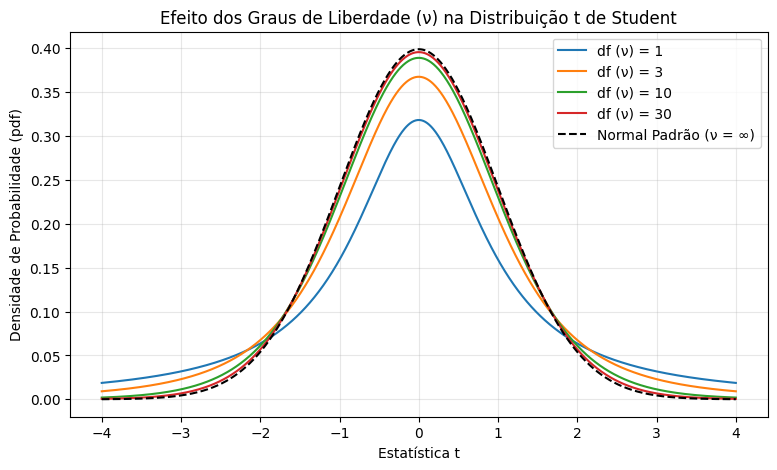

In [ ]:
##2.4 Gráficos em Python: Efeito dos Graus de Liberdade ($\nu$)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Valores para o eixo X (estatística t)
x = np.linspace(-4, 4, 1000)

plt.figure(figsize=(9, 5))

# Variando o parâmetro nu (graus de liberdade)
for df in [1, 3, 10, 30]:
    plt.plot(x, stats.t.pdf(x, df=df), label=f'df (ν) = {df}')

# Comparação com a Normal Padrão
plt.plot(x, stats.norm.pdf(x), 'k--', label='Normal Padrão (ν = ∞)')

plt.title('Efeito dos Graus de Liberdade (ν) na Distribuição t de Student')
plt.xlabel('Estatística t')
plt.ylabel('Densidade de Probabilidade (pdf)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Discussão das mudanças: Aumentar $\nu$ diminui a dispersão nas caudas e eleva o pico central, aproximando a curva da distribuição normal.

##2.5 Condições Necessárias e Limitações da Base Iris
Condições para uso: A variável original de onde a amostra foi retirada deve seguir uma distribuição aproximadamente Normal.

Limitações da base Iris: A base Iris possui poucas observações por espécie ($n = 50$). Se tirarmos subamostras muito pequenas (ex: $n = 5$), o desvio-padrão amostral varia muito, tornando essencial o uso da $t$ de Student em vez da Normal.

1. P(T <= -1.5) = 0.0700
2. P(-1.0 <= T <= 1.0) = 0.6778
3. P(T > 2.0) = 0.0255
4. Percentil 95% (t_c) = 1.6766


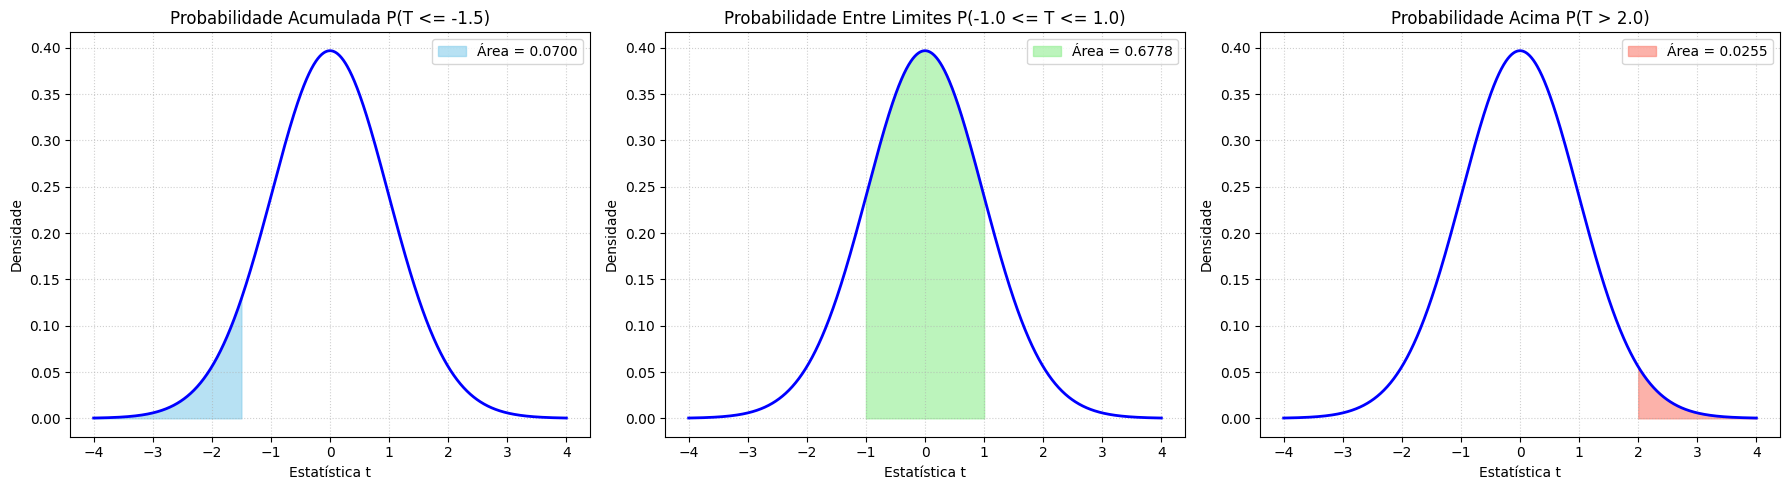

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

df = 49  # Graus de liberdade (n - 1 = 50 - 1)
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=df)

# 1. Probabilidade Acumulada à Esquerda: P(T <= -1.5)
p_acumulada = stats.t.cdf(-1.5, df=df)

# 2. Probabilidade Entre Dois Valores: P(-1.0 <= T <= 1.0)
p_entre = stats.t.cdf(1.0, df=df) - stats.t.cdf(-1.0, df=df)

# 3. Probabilidade Acima de um Valor: P(T > 2.0)
p_acima = stats.t.sf(2.0, df=df)

# 4. Percentil 95%
percentil_95 = stats.t.ppf(0.95, df=df)

print(f"1. P(T <= -1.5) = {p_acumulada:.4f}")
print(f"2. P(-1.0 <= T <= 1.0) = {p_entre:.4f}")
print(f"3. P(T > 2.0) = {p_acima:.4f}")
print(f"4. Percentil 95% (t_c) = {percentil_95:.4f}")

# Visualização gráfica das probabilidades
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: P(T <= -1.5)
axes[0].plot(x, y, "b-", lw=2)
x_fill1 = np.linspace(-4, -1.5, 200)
axes[0].fill_between(
    x_fill1,
    stats.t.pdf(x_fill1, df=df),
    color="skyblue",
    alpha=0.6,
    label=f"Área = {p_acumulada:.4f}",
)
axes[0].set_title("Probabilidade Acumulada P(T <= -1.5)")
axes[0].set_xlabel("Estatística t")
axes[0].set_ylabel("Densidade")
axes[0].legend()
axes[0].grid(True, linestyle=":", alpha=0.6)

# Gráfico 2: P(-1.0 <= T <= 1.0)
axes[1].plot(x, y, "b-", lw=2)
x_fill2 = np.linspace(-1.0, 1.0, 200)
axes[1].fill_between(
    x_fill2,
    stats.t.pdf(x_fill2, df=df),
    color="lightgreen",
    alpha=0.6,
    label=f"Área = {p_entre:.4f}",
)
axes[1].set_title("Probabilidade Entre Limites P(-1.0 <= T <= 1.0)")
axes[1].set_xlabel("Estatística t")
axes[1].set_ylabel("Densidade")
axes[1].legend()
axes[1].grid(True, linestyle=":", alpha=0.6)

# Gráfico 3: P(T > 2.0)
axes[2].plot(x, y, "b-", lw=2)
x_fill3 = np.linspace(2.0, 4.0, 200)
axes[2].fill_between(
    x_fill3,
    stats.t.pdf(x_fill3, df=df),
    color="salmon",
    alpha=0.6,
    label=f"Área = {p_acima:.4f}",
)
axes[2].set_title("Probabilidade Acima P(T > 2.0)")
axes[2].set_xlabel("Estatística t")
axes[2].set_ylabel("Densidade")
axes[2].legend()
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

##3. Qui-quadrado

### Distribuição Qui-quadrado

A distribuição qui-quadrado (χ²) é uma distribuição de probabilidade contínua utilizada em diferentes situações da estatística.

#### 1. Fórmula da função densidade

A função densidade de probabilidade da distribuição qui-quadrado é:

$$
f(x;k)=
\frac{1}{2^{k/2}\Gamma(k/2)}
x^{k/2-1}e^{-x/2},
\qquad x\geq 0
$$

em que:

- x = valor que a variável aleatória qui-quadrado pode assumir;
- k = número de graus de liberdade da distribuição;
- e = constante matemática, aproximadamente igual a 2,718;
- $\Gamma$ = função Gama, uma função matemática utilizada na definição da distribuição;
- f(x;k) = valor da função densidade no ponto $x$.

O parâmetro $k$ representa os graus de liberdade e deve ser maior que zero (k>0). A distribuição qui-quadrado pode assumir apenas valores iguais ou maiores que zero.

A área sob a curva da função densidade representa probabilidades. Portanto, o valor de f(x;k) em um único ponto não corresponde diretamente a uma probabilidade.

#### B. Representação prática e diferenciação conceitual

A distribuição qui-quadrado não representa diretamente uma medida de um organismo, como o comprimento de uma pétala, a massa de uma ave ou a altura de uma planta. Essas são medidas biológicas obtidas diretamente dos organismos.

A distribuição qui-quadrado é utilizada para representar o comportamento de uma estatística calculada a partir de uma amostra.

Por exemplo, podemos coletar o comprimento das pétalas de várias plantas. Os valores medidos, como 4,2 cm, 4,5 cm e 5,0 cm, são dados biológicos individuais. A partir desses dados, podemos calcular uma estatística, como a variância amostral ($S^2$), que indica o quanto os valores da amostra variam entre si.

Em determinadas condições, principalmente quando os dados vêm de uma população com distribuição Normal, a variância amostral pode ser transformada em uma estatística que segue uma distribuição qui-quadrado:

$$
\chi^2=\frac{(n-1)S^2}{\sigma_0^2}
$$

em que:

- n = tamanho da amostra;
- S^2 = variância calculada a partir da amostra;
- $\sigma_0^2$ = variância da população considerada como referência;
- n-1 = graus de liberdade.

Assim, os valores individuais observados nos organismos são utilizados para calcular uma estatística. A distribuição qui-quadrado descreve os possíveis valores dessa estatística quando as condições necessárias são atendidas.

#### C. Parâmetros e seus efeitos sobre a curva

O principal parâmetro da distribuição qui-quadrado é o número de graus de liberdade, representado por k ou df.

Para a distribuição qui-quadrado:


k=df>0


Portanto, os graus de liberdade devem assumir valores maiores que zero.

Os graus de liberdade determinam a forma e a posição da distribuição. Algumas características importantes são:

- Média: $E(X)=k$
- Variância: $Var(X)=2k$
- Desvio-padrão: $\sqrt{2k}$

Quando o número de graus de liberdade aumenta, a média da distribuição também aumenta. Por isso, a curva tende a se deslocar para a direita. A variância também aumenta, fazendo com que a distribuição apresente maior dispersão em termos absolutos. Além disso, a distribuição qui-quadrado é assimétrica à direita quando possui poucos graus de liberdade. Conforme os graus de liberdade aumentam, a assimetria diminui e a distribuição se torna mais parecida com uma distribuição Normal.

#### D. Condições de aplicação e limitações do banco de dados

Uma das principais limitações é que a aplicação clássica da distribuição qui-quadrado para variâncias depende da hipótese de normalidade. Quando os dados apresentam forte desvio da normalidade, a relação teórica com a distribuição qui-quadrado pode não ser adequada.

Além disso, uma amostra pequena pode representar de maneira limitada a população estudada. Portanto, os resultados devem ser interpretados considerando o tamanho da amostra, a forma de obtenção dos dados e as características da população analisada.

Por fim, é importante diferenciar a distribuição teórica dos dados observados. A distribuição qui-quadrado descreve o comportamento esperado de uma estatística sob determinadas condições; ela não significa que os dados biológicos individuais necessariamente tenham distribuição qui-quadrado.





##4. F-Fisher

### F de Fisher-Snedecor

A distribuição F de Fisher-Snedecor é uma distribuição de probabilidade contínua que surge naturalmente na inferência estatística, principalmente na comparação de variâncias de duas populações independentes.

#### A. Função densidade de probabilidade

A função de densidade de probabilidade para uma variável aleatória contínua $X$ que segue uma distribuição F, denotada por $X \sim F(d_1, d_2)$, é definida por:

$$f(x) = \frac{\sqrt{\frac{(d_1 x)^{d_1} d_2^{d_2}}{(d_1 x + d_2)^{d_1 + d_2}}}}{x \cdot B\left(\frac{d_1}{2}, \frac{d_2}{2}\right)} \quad \text{para } x > 0$$

Onde:
* $x \in \mathbb{R}^+$: o valor da estatística de teste (razão de variâncias, sempre estritamente positivo).
* $d_1 \in \mathbb{I}^+$: graus de liberdade do numerador.
* $d_2 \in \mathbb{I}^+$: graus de liberdade do denominador.
* $B(\alpha, \beta)$: a função Beta, que atua como constante de normalização para que a área total sob a curva seja igual a 1.

#### B. Representação prática e diferenciação conceitual
* **Medida de um organismo:** É conceitualmente incorreto afirmar que o comprimento ou largura de uma estrutura física individual (como a sépala ou a pétala de uma flor) segue uma distribuição F. Características físicas contínuas individuais são modeladas por distribuições como a Normal.
* **Estatística calculada a partir de amostras:** A distribuição F descreve especificamente o comportamento de uma estatística amostral: a **razão entre duas variâncias amostrais corrigidas** provenientes de populações normais e independentes. Se extraímos uma amostra de tamanho $n_1$ de uma população com variância $\sigma_1^2$ e outra amostra independente de tamanho $n_2$ de uma população com variância $\sigma_2^2$, a estatística:

$$F = \frac{S_1^2 / \sigma_1^2}{S_2^2 / \sigma_2^2}$$

segue uma distribuição $F(d_1 = n_1 - 1, \, d_2 = n_2 - 1)$. Sob a hipótese nula de igualdade de variâncias populacionais ($H_0: \sigma_1^2 = \sigma_2^2$), a fórmula simplifica-se para a razão direta das variâncias amostrais:

$$F = \frac{S_1^2}{S_2^2}$$

#### C. Parâmetros e seus efeitos sobre a curva
Os parâmetros admissíveis são inteiros estritamente positivos ($d_1, d_2 \ge 1$).
* **Assimetria Positiva:** A curva F é estritamente positiva ($x > 0$) e apresenta assimetria à direita (cauda direita longa).
* **Efeito de $d_1$ (graus de liberdade do numerador):** Controla principalmente a forma do pico próximo à origem. Para $d_1 = 1$ ou $d_1 = 2$, a curva é decrescente a partir de um pico infinito ou alto na origem. Para $d_1 > 2$, a curva assume o formato clássico assimétrico com pico unimodal deslocado à direita do zero.
* **Efeito de $d_2$ (graus de liberdade do denominador):** Controla a espessura das caudas (dispersão). Valores pequenos de $d_2$ produzem caudas muito pesadas e dispersas. À medida que $d_2 \to \infty$, a distribuição F aproxima-se de uma distribuição Qui-quadrado escalonada.

#### D. Condições de aplicação e limitações do banco de dados
Para aplicar rigorosamente a distribuição F para comparar as variâncias de características físicas entre duas espécies de Iris, devemos assumir:
1. **Normalidade:** As populações das quais as amostras foram extraídas devem ser distribuídas normalmente.
2. **Independência:** As observações de cada espécie devem ser independentes entre si e os dois grupos devem ser mutuamente independentes.

*Limitação Prática:* Amostras pequenas (como $n = 50$ na base Iris) aumentam a sensibilidade a desvios moderados da normalidade, o que pode distorcer o nível de significância nominal do teste F.

### 4.2 Perguntas de pesquisa

**Contexto biológico:**
Um botânico deseja avaliar se a variabilidade (dispersão) na **largura da sépala** (*sepal width*) é estatisticamente diferente entre a espécie **Iris-setosa** e a espécie **Iris-versicolor**. Ele sabe que ambas as características físicas seguem aproximadamente distribuições normais dentro de cada espécie.

Para isso, coletou-se uma amostra aleatória de cada grupo:
* Grupo 1 ($1$): $n_1 = 50$ observações de *Iris-setosa*.
* Grupo 2 ($2$): $n_2 = 50$ observações de *Iris-versicolor*.

Os graus de liberdade associados ao numerador e denominador para a nossa distribuição de referência sob a hipótese nula ($H_0: \sigma_1^2 = \sigma_2^2$) são:
* $d_1 = n_1 - 1 = 49$
* $d_2 = n_2 - 1 = 49$

A estatística amostral calculada é a razão de variâncias amostrais corrigidas: $F_{\text{amostral}} = S_1^2 / S_2^2$. Sob a hipótese nula de que ambas as espécies possuem exatamente a mesma variância populacional, a variável aleatória $F$ segue uma distribuição $F(49, 49)$.

1. Se as variâncias populacionais forem idênticas, qual a probabilidade de obtermos, puramente por acaso amostral, uma razão de variâncias menor que $0.60$ (indicando que a variabilidade da *Setosa* foi consideravelmente menor que a da *Versicolor*)?
2. Qual a probabilidade de a razão de variâncias amostrais situar-se em um intervalo considerado "típico e neutro" para a hipótese nula, entre $0.80$ e $1.20$?
3. Qual a probabilidade de obtermos uma razão de variâncias superior a $1.80$ (indicando que a variabilidade da *Setosa* foi consideravelmente maior)?
4. Qual é o valor limite crítico da razão de variâncias (percentil 95) acima do qual encontram-se apenas os 5% casos mais extremos a favor de maior variabilidade da *Setosa*?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Garante que os dados estão carregados lendo diretamente do link oficial do repositório UCI
try:
    df_completo
except NameError:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
    columns = ['sepal length', 'sepal width', 'petal length', 'petal width', 'class']
    df_completo = pd.read_csv(url, header=None, names=columns)

# Amostras do Iris dataset
setosa_sw = df_completo[df_completo['class'] == 'Iris-setosa']['sepal width']
versicolor_sw = df_completo[df_completo['class'] == 'Iris-versicolor']['sepal width']

# Calculando as variâncias amostrais reais para o contexto
s1_sq = setosa_sw.var(ddof=1)
s2_sq = versicolor_sw.var(ddof=1)
f_amostral = s1_sq / s2_sq

# Definição dos parâmetros da Distribuição F sob H0
n1, n2 = len(setosa_sw), len(versicolor_sw)
d1 = n1 - 1
d2 = n2 - 1

# 1. Cálculos de probabilidades usando a biblioteca scipy.stats
# cdf(x) = probabilidade acumulada à esquerda
p_abaixo = stats.f.cdf(0.60, d1, d2)
# cdf(b) - cdf(a) = probabilidade entre dois limites
p_entre = stats.f.cdf(1.20, d1, d2) - stats.f.cdf(0.80, d1, d2)
# sf(x) = survival function (1 - cdf), probabilidade acumulada à direita
p_acima = stats.f.sf(1.80, d1, d2)
# ppf(q) = percentpoint function (inversa da cdf), calcula percentis
percentil_95 = stats.f.ppf(0.95, d1, d2)

print(f"--- RESULTADOS ESTATÍSTICOS (Iris Sepal Width: Setosa vs Versicolor) ---")
print(f"Variância Amostral Setosa (S1^2): {s1_sq:.4f}")
print(f"Variância Amostral Versicolor (S2^2): {s2_sq:.4f}")
print(f"Razão de Variâncias Amostral (F_amostral = S1^2 / S2^2): {f_amostral:.4f}\n")
print(f"--- PROBABILIDADES SOB A HIPÓTESE NULA F({d1}, {d2}) ---")
print(f"1. P(F < 0.60)           = {p_abaixo:.4f} ({p_abaixo*100:.2f}%)")
print(f"2. P(0.80 < F < 1.20)     = {p_entre:.4f} ({p_entre*100:.2f}%)")
print(f"3. P(F > 1.80)           = {p_acima:.4f} ({p_acima*100:.2f}%)")
print(f"4. Percentil 95 (Limite) = {percentil_95:.4f} (apenas 5% das razões de variâncias superam este valor por acaso)")

--- RESULTADOS ESTATÍSTICOS (Iris Sepal Width: Setosa vs Versicolor) ---
Variância Amostral Setosa (S1^2): 0.1452
Variância Amostral Versicolor (S2^2): 0.0985
Razão de Variâncias Amostral (F_amostral = S1^2 / S2^2): 1.4744

--- PROBABILIDADES SOB A HIPÓTESE NULA F(49, 49) ---
1. P(F < 0.60)           = 0.0384 (3.84%)
2. P(0.80 < F < 1.20)     = 0.5183 (51.83%)
3. P(F > 1.80)           = 0.0211 (2.11%)
4. Percentil 95 (Limite) = 1.6073 (apenas 5% das razões de variâncias superam este valor por acaso)


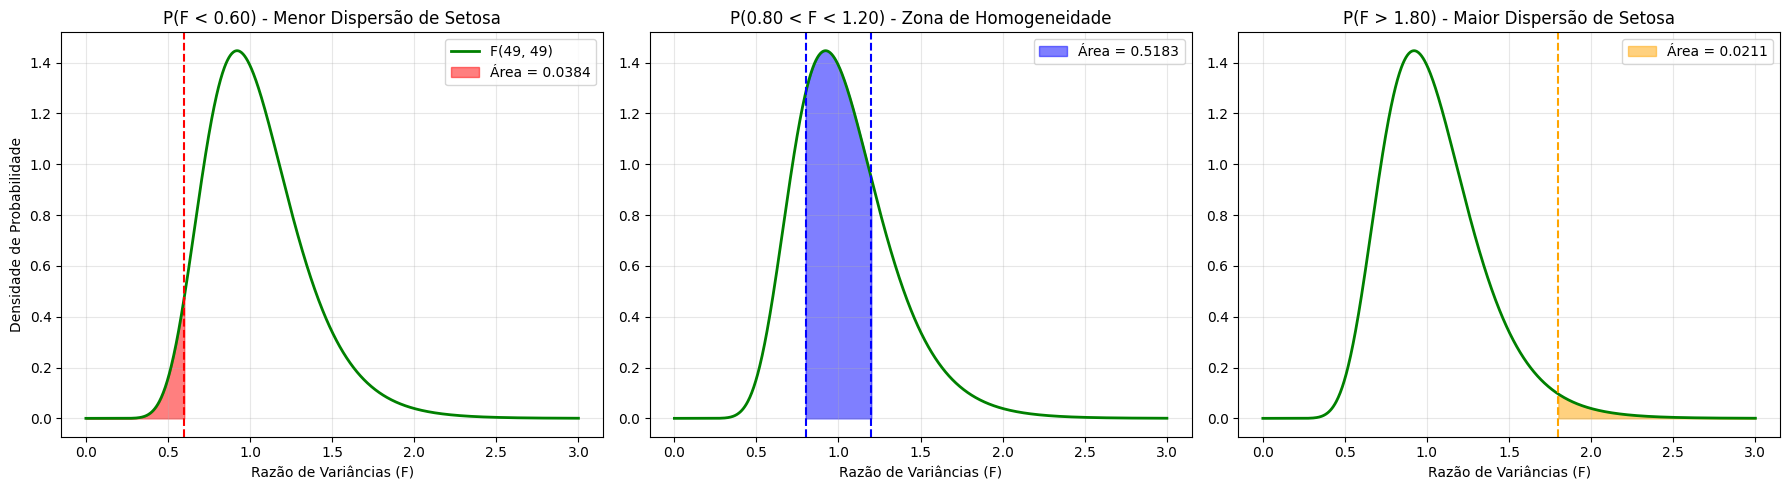

In [ ]:
# 2. Plotagem das curvas e áreas sombreadas para a distribuição F
x = np.linspace(0.001, 3.0, 1000)
y_pdf = stats.f.pdf(x, d1, d2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: P(F < 0.60)
axes[0].plot(x, y_pdf, 'g-', lw=2, label=f'F({d1}, {d2})')
x_fill1 = np.linspace(0.001, 0.60, 500)
axes[0].fill_between(x_fill1, stats.f.pdf(x_fill1, d1, d2), color='red', alpha=0.5,
                     label=f'Área = {p_abaixo:.4f}')
axes[0].axvline(0.60, color='red', linestyle='--')
axes[0].set_title('P(F < 0.60) - Menor Dispersão de Setosa')
axes[0].set_xlabel('Razão de Variâncias (F)')
axes[0].set_ylabel('Densidade de Probabilidade')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: P(0.80 < F < 1.20)
axes[1].plot(x, y_pdf, 'g-', lw=2)
x_fill2 = np.linspace(0.80, 1.20, 500)
axes[1].fill_between(x_fill2, stats.f.pdf(x_fill2, d1, d2), color='blue', alpha=0.5,
                     label=f'Área = {p_entre:.4f}')
axes[1].axvline(0.80, color='blue', linestyle='--')
axes[1].axvline(1.20, color='blue', linestyle='--')
axes[1].set_title('P(0.80 < F < 1.20) - Zona de Homogeneidade')
axes[1].set_xlabel('Razão de Variâncias (F)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Gráfico 3: P(F > 1.80)
axes[2].plot(x, y_pdf, 'g-', lw=2)
x_fill3 = np.linspace(1.80, 3.0, 500)
axes[2].fill_between(x_fill3, stats.f.pdf(x_fill3, d1, d2), color='orange', alpha=0.5,
                     label=f'Área = {p_acima:.4f}')
axes[2].axvline(1.80, color='orange', linestyle='--')
axes[2].set_title('P(F > 1.80) - Maior Dispersão de Setosa')
axes[2].set_xlabel('Razão de Variâncias (F)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Análise, comparação visual e discussão

* **Comparação teórica vs área sombreada:**
  * No **Gráfico 1**, a área vermelha representa a probabilidade teórica de obtermos uma razão amostral menor ou igual a $0.60$ quando as variâncias populacionais reais são iguais. Essa probabilidade calculada é de **3.84%**.
  * No **Gráfico 2**, a faixa azul central de $0.80$ a $1.20$ cobre o pico principal da densidade. Essa área representa **51.83%** de probabilidade, ilustrando que pouco mais da metade dos sorteios amostrais gerará razões próximas de 1.
  * No **Gráfico 3**, a cauda direita laranja acima do limiar de $1.80$ corresponde a uma probabilidade de apenas **2.11%** de ocorrência casual.

* **Interpretação do limite crítico (Percentil 95):**
  * O **Percentil 95** obtido para a distribuição $F(49, 49)$ foi de **1.6073**.
  * Isso nos diz que, sob a hipótese nula de variâncias populacionais iguais ($H_0$), haveria apenas $5\%$ de chance de coletarmos amostras que gerem uma estatística F maior que $1.6073$.

* **Conexão com os dados reais do banco de dados:**
  * A razão de variâncias amostrais observada nos nossos dados reais é:
    $$F_{\text{amostral}} = \frac{S^2_{\text{setosa}}}{S^2_{\text{versicolor}}} = \frac{0.1452}{0.0985} \approx 1.4744$$
  * Uma vez que $1.4744 < 1.6073$, a nossa estatística amostral está abaixo do limite do percentil 95. Portanto, sob o nível clássico de significância de 5%, não rejeitaríamos a hipótese nula de que a variabilidade da largura da sépala nas duas espécies de Iris é estatisticamente idêntica na população de origem.